<a href="https://colab.research.google.com/github/NeybaT/collab12/blob/main/Artificial_intelligence_enhanced_FTIR_spectroscopy_for_simultaneous_multicomponent_carbohydrate_quantification_in_dairy_matrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import os
import glob
import re

import matplotlib.pyplot as plt

from scipy.signal import savgol_filter

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

Mounted at /content/drive


In [ ]:

FULL_GRID = np.linspace(880,1100,500)
COMMON_GRID = FULL_GRID.copy()

In [ ]:
def load_spectrum(file_path):

    if file_path.lower().endswith(".csv"):
        data = pd.read_csv(file_path, header=None)
    else:
        data = pd.read_excel(file_path, header=None)

    data = data.apply(pd.to_numeric, errors="coerce")
    data = data.dropna()

    x = data.iloc[:,0].values
    y = data.iloc[:,1].values

    if x[0] > x[-1]:
        x = x[::-1]
        y = y[::-1]

    y_interp = np.interp(FULL_GRID, x, y)

    return y_interp

In [ ]:
dataset_path = "/content/drive/"

files = []

files += glob.glob(os.path.join(dataset_path, "**/*.xlsx"), recursive=True)
files += glob.glob(os.path.join(dataset_path, "**/*.xls"), recursive=True)
files += glob.glob(os.path.join(dataset_path, "**/*.csv"), recursive=True)

print("Archivos encontrados:", len(files))

Archivos encontrados: 861


In [ ]:
pattern = r"G(\d+\.?\d*)Glt(\d+\.?\d*)L(\d+\.?\d*)"

X = []
y = []

for file in files:

    spectrum = load_spectrum(file)

    name = os.path.basename(file)
    match = re.search(pattern, name)

    if match is None:
        continue

    g = float(match.group(1))
    glt = float(match.group(2))
    l = float(match.group(3))

    X.append(spectrum)
    y.append([g, glt, l])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(861, 500)
(861, 3)


In [ ]:
X = savgol_filter(X, window_length=11, polyorder=2, deriv=2)

In [ ]:
def snv(input_data):

    output = np.zeros_like(input_data)

    for i in range(input_data.shape[0]):
        spectrum = input_data[i]
        output[i] = (spectrum - np.mean(spectrum)) / np.std(spectrum)

    return output

X = snv(X)

In [ ]:
lactose_band   = (FULL_GRID >= 850) & (FULL_GRID <= 900)
galactose_band = (FULL_GRID >= 910) & (FULL_GRID <= 930)
glucose_band   = (FULL_GRID >= 950) & (FULL_GRID <= 970)


extra_band = (FULL_GRID >= 1000) & (FULL_GRID <= 1100)


spectral_mask = lactose_band | galactose_band | glucose_band | extra_band

In [ ]:
X = X[:, spectral_mask]

COMMON_GRID = FULL_GRID[spectral_mask]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
components = range(2,20)

scores = []

for n in components:

    pls = PLSRegression(n_components=n)

    y_cv = cross_val_predict(pls,X_train_scaled,y_train,cv=5)

    score = r2_score(y_train,y_cv,multioutput="variance_weighted")

    scores.append(score)

best_n = components[np.argmax(scores)]

print("Best components:",best_n)

Best components: 19


In [ ]:
pls = PLSRegression(n_components=best_n)

pls.fit(X_train_scaled,y_train)

y_pred_pls = pls.predict(X_test_scaled)

In [ ]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(3, activation='linear'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1050.3779 - mae: 19.7999 - val_loss: 442.8359 - val_mae: 13.4064
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 283.9478 - mae: 11.2824 - val_loss: 181.9342 - val_mae: 8.3666
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 165.3910 - mae: 8.3910 - val_loss: 111.5508 - val_mae: 6.1752
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 132.8493 - mae: 7.4108 - val_loss: 70.5529 - val_mae: 5.0675
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 110.6599 - mae: 6.7016 - val_loss: 55.1865 - val_mae: 4.6644
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92.8143 - mae: 6.1504 - val_loss: 48.1147 - val_mae: 4.1538
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 88.4845 - mae: 5.8683 - val_loss: 44.0399 - val_mae: 3.7914
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 84.6639 - mae: 5.8540 - val_loss: 49.0629 - val_mae: 4.3479
Epoch 9/200
35/35 ━━━━━━━━━━━━━━━━━

In [ ]:
y_pred_ann = model.predict(X_test_scaled)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
models = {
    "PLS": y_pred_pls,
    "ANN": y_pred_ann
}

for name,preds in models.items():

    print("\n",name)

    for i,comp in enumerate(["Glucose","Galactose","Lactose"]):

        r2 = r2_score(y_test[:,i],preds[:,i])
        mae = mean_absolute_error(y_test[:,i],preds[:,i])

        print(comp)
        print("R2:",r2)
        print("MAE:",mae)


 PLS
Glucose
R2: 0.892237875074591
MAE: 4.334167138303077
Galactose
R2: 0.9640486296327986
MAE: 3.616943901437001
Lactose
R2: 0.9688669901234829
MAE: 3.7620390391793843

 ANN
Glucose
R2: 0.9152376985651892
MAE: 3.290495701938695
Galactose
R2: 0.9395541729040106
MAE: 5.111107082036189
Lactose
R2: 0.9707871650294427
MAE: 4.212781464943307


In [ ]:
commercial_path = "/content/drive/"

commercial_files = []

commercial_files += glob.glob(os.path.join(commercial_path, "*.xlsx"))
commercial_files += glob.glob(os.path.join(commercial_path, "*.xls"))
commercial_files += glob.glob(os.path.join(commercial_path, "*.csv"))

print("Muestras comerciales encontradas:", len(commercial_files))

for f in commercial_files[:5]:
    print(os.path.basename(f))

Muestras comerciales encontradas: 8
Regular.xlsx
CRM.xlsx
Lowlactose.xlsx
Galactose.xlsx
Glucose.xlsx


In [ ]:
def preprocess_commercial(file):

    spectrum = load_spectrum(file)

    spectrum = savgol_filter(spectrum,11,2,deriv=2)

    spectrum = snv(spectrum.reshape(1,-1))

    spectrum = spectrum[:, spectral_mask]

    spectrum = scaler.transform(spectrum)

    return spectrum

In [ ]:
y_pred = y_pred_ann

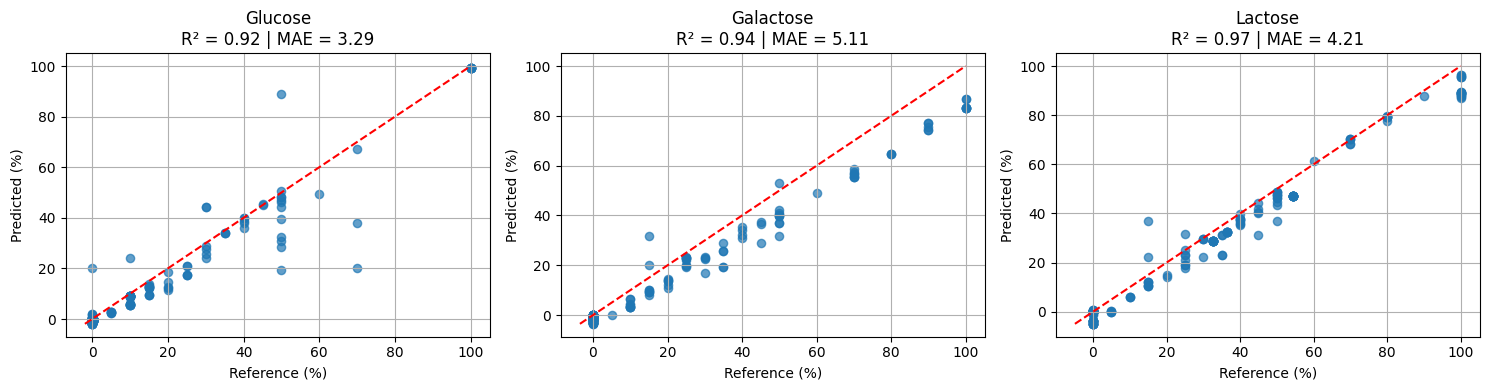

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

components = ["Glucose","Galactose","Lactose"]

fig, axes = plt.subplots(1,3, figsize=(15,4))

for i, comp in enumerate(components):

    ax = axes[i]

    true_vals = y_test[:,i]
    pred_vals = y_pred[:,i]

    r2 = r2_score(true_vals, pred_vals)
    mae = mean_absolute_error(true_vals, pred_vals)

    ax.scatter(true_vals, pred_vals, s=35, alpha=0.7)

    lims = [
        min(true_vals.min(), pred_vals.min()),
        max(true_vals.max(), pred_vals.max())
    ]

    ax.plot(lims, lims, 'r--')

    ax.set_xlabel("Reference (%)")
    ax.set_ylabel("Predicted (%)")

    ax.set_title(f"{comp}\nR² = {r2:.2f} | MAE = {mae:.2f}")

    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
models = {
"PLS": y_pred_pls,
"ANN": y_pred_ann
}

for name, preds in models.items():

    print("\n", name)

    for i, comp in enumerate(["Glucose","Galactose","Lactose"]):

        r2 = r2_score(y_test[:,i], preds[:,i])

        print(comp, "R2:", r2)


 PLS
Glucose R2: 0.892237875074591
Galactose R2: 0.9640486296327986
Lactose R2: 0.9688669901234829

 ANN
Glucose R2: 0.9152376985651892
Galactose R2: 0.9395541729040106
Lactose R2: 0.9707871650294427


In [ ]:

import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

components = ["Glucose","Galactose","Lactose"]

rows = []

for i, comp in enumerate(components):

    # PLS
    r2_pls = r2_score(y_test[:,i], y_pred_pls[:,i])
    mae_pls = mean_absolute_error(y_test[:,i], y_pred_pls[:,i])
    rmse_pls = np.sqrt(mean_squared_error(y_test[:,i], y_pred_pls[:,i]))

    # ANN
    r2_ann = r2_score(y_test[:,i], y_pred_ann[:,i])
    mae_ann = mean_absolute_error(y_test[:,i], y_pred_ann[:,i])
    rmse_ann = np.sqrt(mean_squared_error(y_test[:,i], y_pred_ann[:,i]))

    rows.append([
        comp,
        r2_pls, mae_pls, rmse_pls,
        r2_ann, mae_ann, rmse_ann
    ])

comparison_table = pd.DataFrame(
    rows,
    columns=[
        "Carbohydrate",
        "PLS R2","PLS MAE","PLS RMSE",
        "ANN R2","ANN MAE","ANN RMSE"
    ]
)

comparison_table

,Carbohydrate,PLS R2,PLS MAE,PLS RMSE,ANN R2,ANN MAE,ANN RMSE
0,Glucose,0.892238,4.334167,8.291920,0.915238,3.290496,7.353996
1,Galactose,0.964049,3.616944,5.709117,0.939554,5.111107,7.402772
2,Lactose,0.968867,3.762039,5.730926,0.970787,4.212781,5.551382


In [ ]:

rows = []

for i, comp in enumerate(components):

    r2 = r2_score(y_test[:,i], y_pred_ann[:,i])
    mae = mean_absolute_error(y_test[:,i], y_pred_ann[:,i])
    rmse = np.sqrt(mean_squared_error(y_test[:,i], y_pred_ann[:,i]))

    rows.append([comp, r2, mae, rmse])

final_metrics = pd.DataFrame(
    rows,
    columns=["Carbohydrate","R2","MAE","RMSE"]
)

final_metrics

,Carbohydrate,R2,MAE,RMSE
0,Glucose,0.915238,3.290496,7.353996
1,Galactose,0.939554,5.111107,7.402772
2,Lactose,0.970787,4.212781,5.551382


In [ ]:

!pip install python-ternary

import ternary

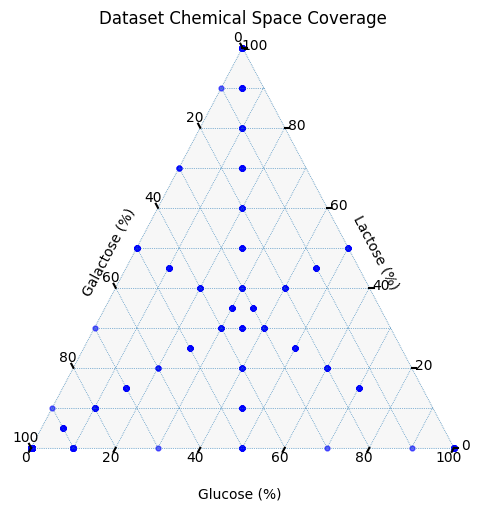

In [ ]:
import ternary
import matplotlib.pyplot as plt

scale = 100

figure, tax = ternary.figure(scale=scale)
figure.set_size_inches(6,6)

points = [tuple(row) for row in y]

tax.scatter(points, marker='o', color='blue', alpha=0.6, s=12)

tax.left_axis_label("Galactose (%)")
tax.right_axis_label("Lactose (%)")
tax.bottom_axis_label("Glucose (%)")



tax.gridlines(multiple=10)

tax.set_title("Dataset Chemical Space Coverage")

tax.ticks(axis='lbr', multiple=20)

tax.clear_matplotlib_ticks()


ax = tax.get_axes()
for spine in ax.spines.values():
    spine.set_visible(False)

    ax = tax.get_axes()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

/usr/local/lib/python3.12/dist-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


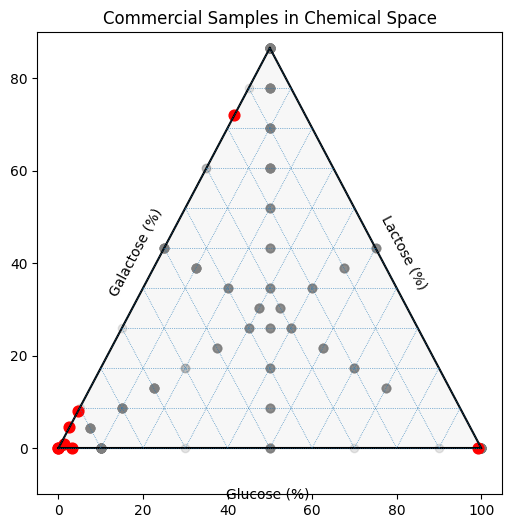

In [ ]:
commercial_points = results_df[
["Glucose (%)","Galactose (%)","Lactose (%)"]
].values

figure, tax = ternary.figure(scale=scale)
figure.set_size_inches(6,6)

dataset_points = [tuple(row) for row in y]

tax.scatter(dataset_points, color="gray", alpha=0.2)

tax.scatter(
[tuple(row) for row in commercial_points],
color="red",
s=60
)

tax.left_axis_label("Galactose (%)")
tax.right_axis_label("Lactose (%)")
tax.bottom_axis_label("Glucose (%)")

tax.boundary()
tax.gridlines(multiple=10)

tax.set_title("Commercial Samples in Chemical Space")

plt.show()

In [ ]:

!pip install python-ternary

import ternary

In [ ]:
def calculate_vip(pls, X, y):

    t = pls.x_scores_
    w = pls.x_weights_
    q = pls.y_loadings_

    p, h = w.shape
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)

    total_s = np.sum(s)

    vip = np.zeros((p,))

    for i in range(p):

        weight = np.array([(w[i,j]**2) * s[j] for j in range(h)])

        vip[i] = np.sqrt(p * np.sum(weight) / total_s)

    return vip

In [ ]:
vip_scores = calculate_vip(pls, X_train_scaled, y_train)

In [ ]:
from scipy.signal import savgol_filter

vip_smooth = savgol_filter(vip_scores, 21, 3)

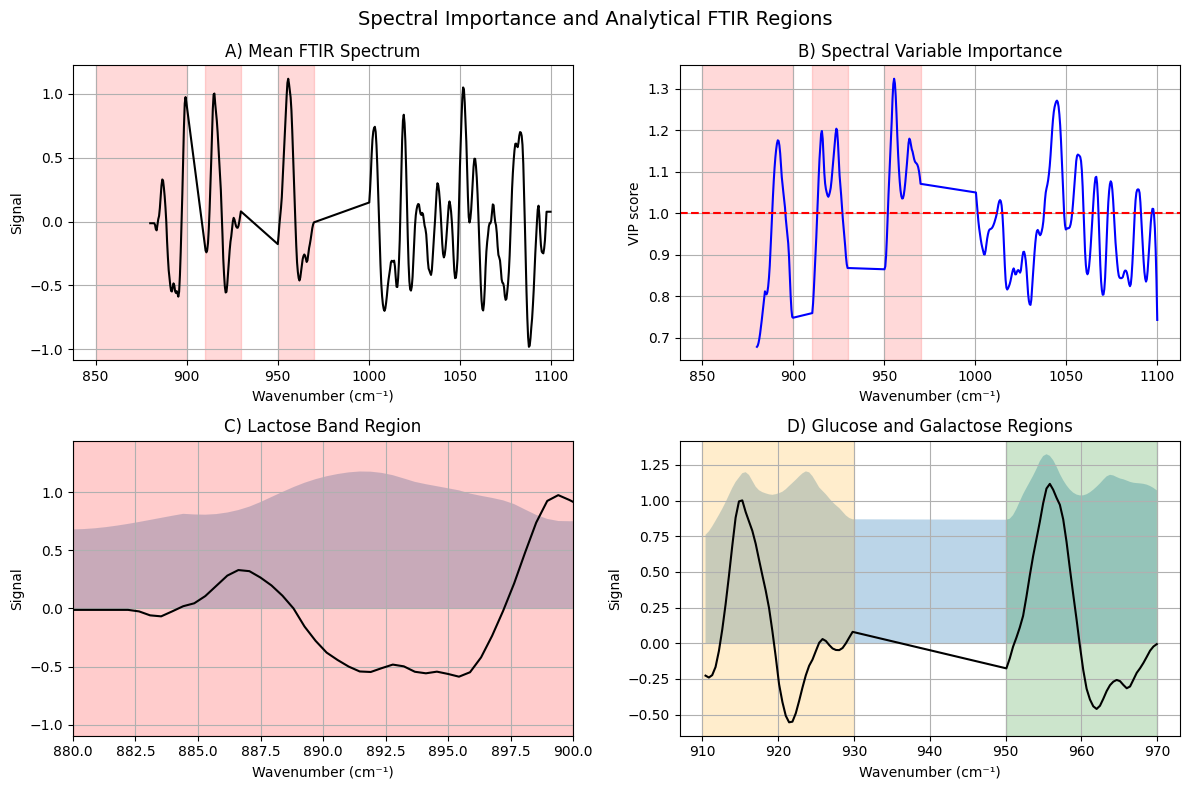

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter


mean_spectrum = np.mean(X_train, axis=0)


vip_smooth = savgol_filter(vip_scores, 21, 3)

bands = {
"Lactose": (850,900),
"Galactose": (910,930),
"Glucose": (950,970)
}

fig, axs = plt.subplots(2,2, figsize=(12,8))

# =========================
# PANEL A
#
# =========================

ax = axs[0,0]

ax.plot(COMMON_GRID, mean_spectrum, color="black", label="Mean FTIR spectrum")

for name,(minv,maxv) in bands.items():
    ax.axvspan(minv,maxv,color="red",alpha=0.15)

ax.set_xlabel("Wavenumber (cm⁻¹)")
ax.set_ylabel("Signal")

ax.set_title("A) Mean FTIR Spectrum")

ax.grid(True)


# =========================
# PANEL B
#
# =========================

ax = axs[0,1]

ax.plot(COMMON_GRID, vip_smooth, color="blue")

ax.axhline(1, linestyle="--", color="red")

for name,(minv,maxv) in bands.items():
    ax.axvspan(minv,maxv,color="red",alpha=0.15)

ax.set_xlabel("Wavenumber (cm⁻¹)")
ax.set_ylabel("VIP score")

ax.set_title("B) Spectral Variable Importance")

ax.grid(True)


# =========================
# PANEL C
#
# =========================


ax = axs[1,0]


ax.plot(COMMON_GRID, mean_spectrum, color="black")


ax.fill_between(COMMON_GRID, 0, vip_smooth, alpha=0.3)


ax.set_xlim(880, 900)

ax.axvspan(880, 900, color="red", alpha=0.2)

ax.set_title("C) Lactose Band Region")

ax.set_xlabel("Wavenumber (cm⁻¹)")
ax.set_ylabel("Signal")

ax.grid(True)

# =========================
# PANEL D
#
# =========================

ax = axs[1,1]

mask = (COMMON_GRID >= 900) & (COMMON_GRID <= 980)

ax.plot(COMMON_GRID[mask], mean_spectrum[mask], color="black")

ax.fill_between(COMMON_GRID[mask],0,vip_smooth[mask],alpha=0.3)

ax.axvspan(910,930,color="orange",alpha=0.2)
ax.axvspan(950,970,color="green",alpha=0.2)

ax.set_title("D) Glucose and Galactose Regions")

ax.set_xlabel("Wavenumber (cm⁻¹)")
ax.set_ylabel("Signal")

ax.grid(True)

plt.suptitle("Spectral Importance and Analytical FTIR Regions", fontsize=14)

plt.tight_layout()

plt.show()

In [ ]:
plt.savefig("Figure_FTIR_Spectral_Importance.png", dpi=600, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

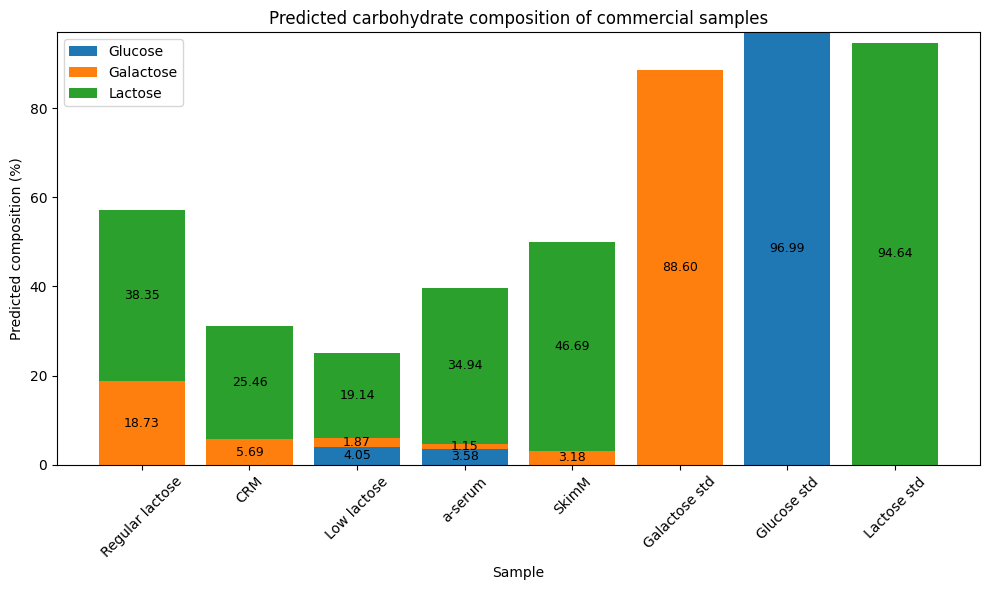

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# Data
# -----------------------------
data = {
    "Sample": [
        "Regular lactose",
        "CRM",
        "Low lactose",
        "a-serum",
        "SkimM",
        "Galactose std",
        "Glucose std",
        "Lactose std"
    ],
    "Glucose (%)": [0, 0, 4.05, 3.58, 0, 0, 96.99, 0],
    "Galactose (%)": [18.73, 5.69, 1.87, 1.15, 3.18, 88.60, 0, 0],
    "Lactose (%)": [38.35, 25.46, 19.14, 34.94, 46.69, 0, 0, 94.64]
}

df = pd.DataFrame(data)

# -----------------------------
# Plot
# -----------------------------
x = np.arange(len(df))

fig, ax = plt.subplots(figsize=(10,6))

bars_glucose = ax.bar(x, df["Glucose (%)"], label="Glucose")
bars_galactose = ax.bar(x, df["Galactose (%)"], bottom=df["Glucose (%)"], label="Galactose")
bars_lactose = ax.bar(
    x,
    df["Lactose (%)"],
    bottom=df["Glucose (%)"] + df["Galactose (%)"],
    label="Lactose"
)


for i in range(len(df)):

    g = df["Glucose (%)"][i]
    ga = df["Galactose (%)"][i]
    l = df["Lactose (%)"][i]

    if g > 0:
        ax.text(i, g/2, f"{g:.2f}", ha='center', va='center', fontsize=9)

    if ga > 0:
        ax.text(i, g + ga/2, f"{ga:.2f}", ha='center', va='center', fontsize=9)

    if l > 0:
        ax.text(i, g + ga + l/2, f"{l:.2f}", ha='center', va='center', fontsize=9)


ax.set_xticks(x)
ax.set_xticklabels(df["Sample"], rotation=45)

ax.set_ylabel("Predicted composition (%)")
ax.set_xlabel("Sample")
ax.set_title("Predicted carbohydrate composition of commercial samples")

ax.legend()

plt.tight_layout()


plt.savefig(
    "carbohydrate_composition_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()